# 🚢 AIS Data — Exploratory Data Analysis

**Objectif :** Explorer les données AIS brutes pour comprendre leur structure,
identifier les valeurs aberrantes, et préparer le pipeline de nettoyage.

**Source :** Marine Cadastre (NOAA) — GeoParquet 2024  
**Auteur :** NaimMG  
**Date :** 2024

## 0. Imports & Configuration

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import folium
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(exist_ok=True)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ Imports OK')
print(f'📁 Raw data files: {list(RAW_DIR.glob("*.parquet"))}')

✅ Imports OK
📁 Raw data files: [PosixPath('../data/raw/ais-2024-01-02.parquet'), PosixPath('../data/raw/ais-2024-01-03.parquet'), PosixPath('../data/raw/ais-2024-01-01.parquet')]


## 1. Chargement des données

In [2]:
# Load first file to inspect structure
file_path = RAW_DIR / 'ais-2024-01-01.parquet'

print(f'📂 Loading {file_path.name}...')
gdf = gpd.read_parquet(file_path)

print(f'✅ Loaded: {len(gdf):,} rows × {len(gdf.columns)} columns')
print(f'💾 Memory usage: {gdf.memory_usage(deep=True).sum() / 1e6:.1f} MB')

📂 Loading ais-2024-01-01.parquet...
✅ Loaded: 7,293,408 rows × 16 columns
💾 Memory usage: 809.8 MB


In [3]:
# First look
gdf.head()

,mmsi,base_date_time,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver,geometry
0,338075892,2024-01-01 00:00:03,0.0000,358.8000,<NA>,PILOT BOAT SPRING PT,,WDB8945,90,0,<NA>,<NA>,<NA>,90,A,POINT (-70.25298 43.65322)
1,367669550,2024-01-01 00:00:04,0.0000,281.9000,141,ALASKA CHALLENGER,IMO7938024,WDH9586,30,<NA>,30.0000,8,<NA>,30,A,POINT (-123.38573 46.20031)
2,367118980,2024-01-01 00:00:06,0.0000,30.1000,296,CAPT J A MORGAN,IMO1186680,WDD2725,31,12,115.0000,34,3.0000,57,A,POINT (-90.40674 29.98534)
3,367177840,2024-01-01 00:00:05,0.0000,304.4000,<NA>,BART TURECAMO,IMO7338808,WBR4464,52,<NA>,33.0000,5,<NA>,52,A,POINT (-75.17649 39.88654)
4,367305420,2024-01-01 00:00:06,0.0000,332.6000,<NA>,DOROTHY MORAN,IMO7716995,WXU4654,52,0,33.0000,11,<NA>,52,A,POINT (-64.95229 18.33273)


In [4]:
# Schema & dtypes
print('=== COLUMNS & TYPES ===')
print(gdf.dtypes)
print(f'\nCRS (coordinate system): {gdf.crs}')

=== COLUMNS & TYPES ===
mmsi                     int32[pyarrow]
base_date_time    timestamp[s][pyarrow]
sog                      float[pyarrow]
cog                      float[pyarrow]
heading                  int32[pyarrow]
vessel_name             string[pyarrow]
imo                     string[pyarrow]
call_sign               string[pyarrow]
vessel_type              int32[pyarrow]
status                   int32[pyarrow]
length                   float[pyarrow]
width                    int32[pyarrow]
draft                    float[pyarrow]
cargo                    int32[pyarrow]
transceiver             string[pyarrow]
geometry                       geometry
dtype: object

CRS (coordinate system): {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "Wo

## 2. Valeurs manquantes

In [5]:
# Missing values analysis
missing = gdf.isnull().sum()
missing_pct = (missing / len(gdf) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print('=== MISSING VALUES ===')
print(missing_df[missing_df['missing_count'] > 0])

=== MISSING VALUES ===
             missing_count  missing_pct
heading            3825775      52.4600
draft              3058798      41.9400
status             2443703      33.5100
cargo              2226088      30.5200
cog                1210318      16.5900
width               216376       2.9700
length              140633       1.9300
vessel_type          38105       0.5200
sog                  16633       0.2300


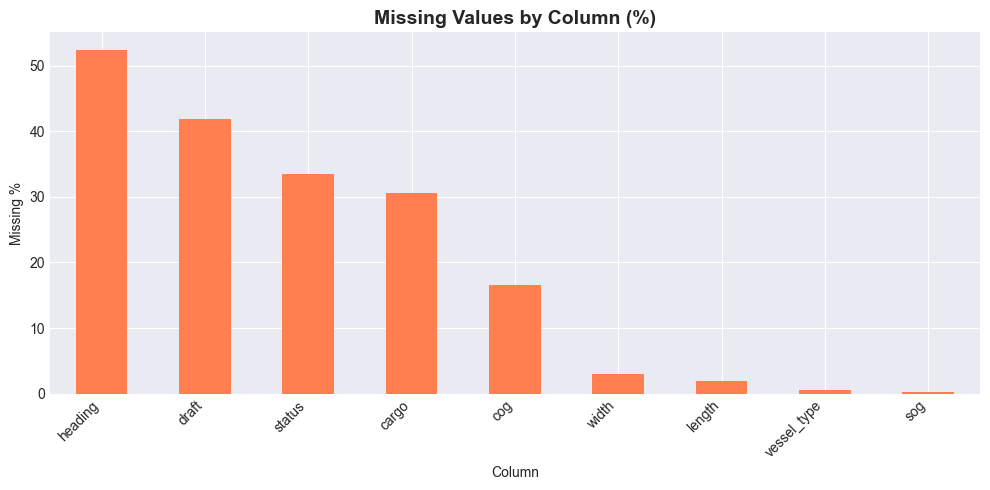

In [6]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 5))
missing_plot = missing_df[missing_df['missing_pct'] > 0]
if len(missing_plot) > 0:
    missing_plot['missing_pct'].plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Missing %')
    ax.set_xlabel('Column')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('✅ No missing values found!')

## 3. Distribution des types de navires

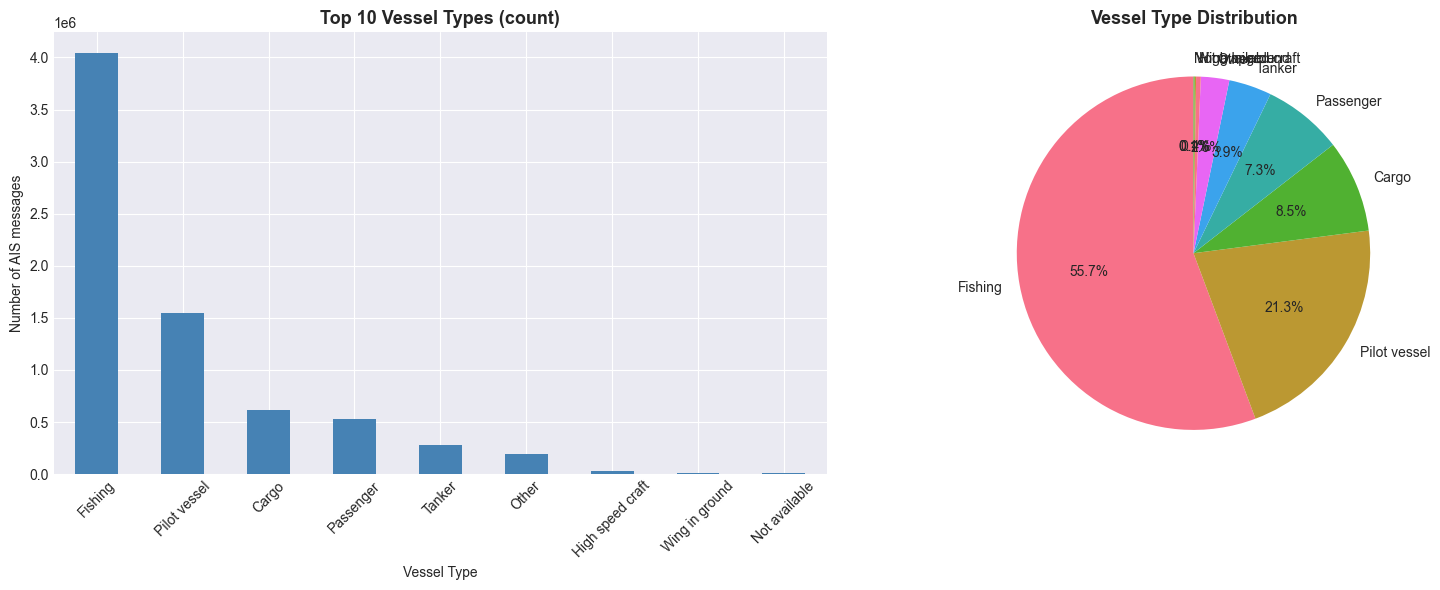


📊 Unique vessel types: 72


In [7]:
# AIS vessel type codes mapping (standard IMO codes)
vessel_type_map = {
    0: 'Not available',
    20: 'Wing in ground',
    30: 'Fishing',
    31: 'Towing',
    32: 'Towing large',
    33: 'Dredging',
    34: 'Diving ops',
    35: 'Military ops',
    36: 'Sailing',
    37: 'Pleasure craft',
    40: 'High speed craft',
    50: 'Pilot vessel',
    51: 'SAR vessel',
    52: 'Tug',
    53: 'Port tender',
    60: 'Passenger',
    70: 'Cargo',
    80: 'Tanker',
    90: 'Other',
}

# Find vessel type column (may vary)
type_col = None
for col in ['VesselType', 'vessel_type', 'type', 'ship_type']:
    if col in gdf.columns:
        type_col = col
        break

if type_col:
    # Map to decade categories for cleaner viz
    gdf['vessel_category'] = (gdf[type_col] // 10 * 10).map(vessel_type_map)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Count plot
    top_types = gdf['vessel_category'].value_counts().head(10)
    top_types.plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Top 10 Vessel Types (count)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Vessel Type')
    axes[0].set_ylabel('Number of AIS messages')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Pie chart
    top_types.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Vessel Type Distribution', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()
    print(f'\n📊 Unique vessel types: {gdf[type_col].nunique()}')
else:
    print('⚠️ Vessel type column not found. Available columns:')
    print(list(gdf.columns))

## 4. Distribution des vitesses

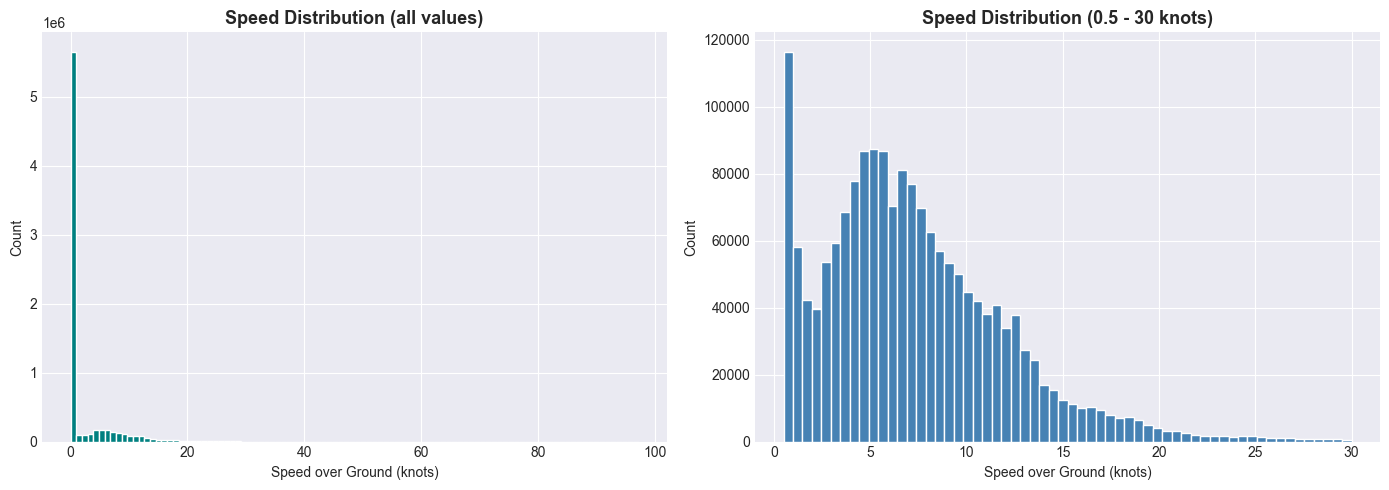


📊 Speed stats:
count   7276775.0000
mean          1.7799
std           3.9768
min           0.0000
25%           0.0000
50%           0.0000
75%           0.3000
max          97.2000
Name: sog, dtype: double[pyarrow]

⚠️  Stopped vessels (SOG < 0.5): 5,531,374 (76.0%)
⚠️  Outliers (SOG > 30): 5,087 (0.1%)


In [8]:
# Find speed column
speed_col = None
for col in ['SOG', 'sog', 'speed', 'Speed']:
    if col in gdf.columns:
        speed_col = col
        break

if speed_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Full distribution
    gdf[speed_col].hist(bins=100, ax=axes[0], color='teal', edgecolor='white')
    axes[0].set_title(f'Speed Distribution (all values)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Speed over Ground (knots)')
    axes[0].set_ylabel('Count')
    
    # Filtered (0-30 knots)
    speed_filtered = gdf[(gdf[speed_col] >= 0.5) & (gdf[speed_col] <= 30)][speed_col]
    speed_filtered.hist(bins=60, ax=axes[1], color='steelblue', edgecolor='white')
    axes[1].set_title('Speed Distribution (0.5 - 30 knots)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Speed over Ground (knots)')
    axes[1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    print(f'\n📊 Speed stats:')
    print(gdf[speed_col].describe())
    print(f'\n⚠️  Stopped vessels (SOG < 0.5): {(gdf[speed_col] < 0.5).sum():,} ({(gdf[speed_col] < 0.5).mean()*100:.1f}%)')
    print(f'⚠️  Outliers (SOG > 30): {(gdf[speed_col] > 30).sum():,} ({(gdf[speed_col] > 30).mean()*100:.1f}%)')
else:
    print('⚠️ Speed column not found. Available columns:')
    print(list(gdf.columns))

## 5. Distribution géographique

=== GEOGRAPHIC COVERAGE ===
Longitude: -160.08 → 145.93
Latitude:  0.12 → 50.38


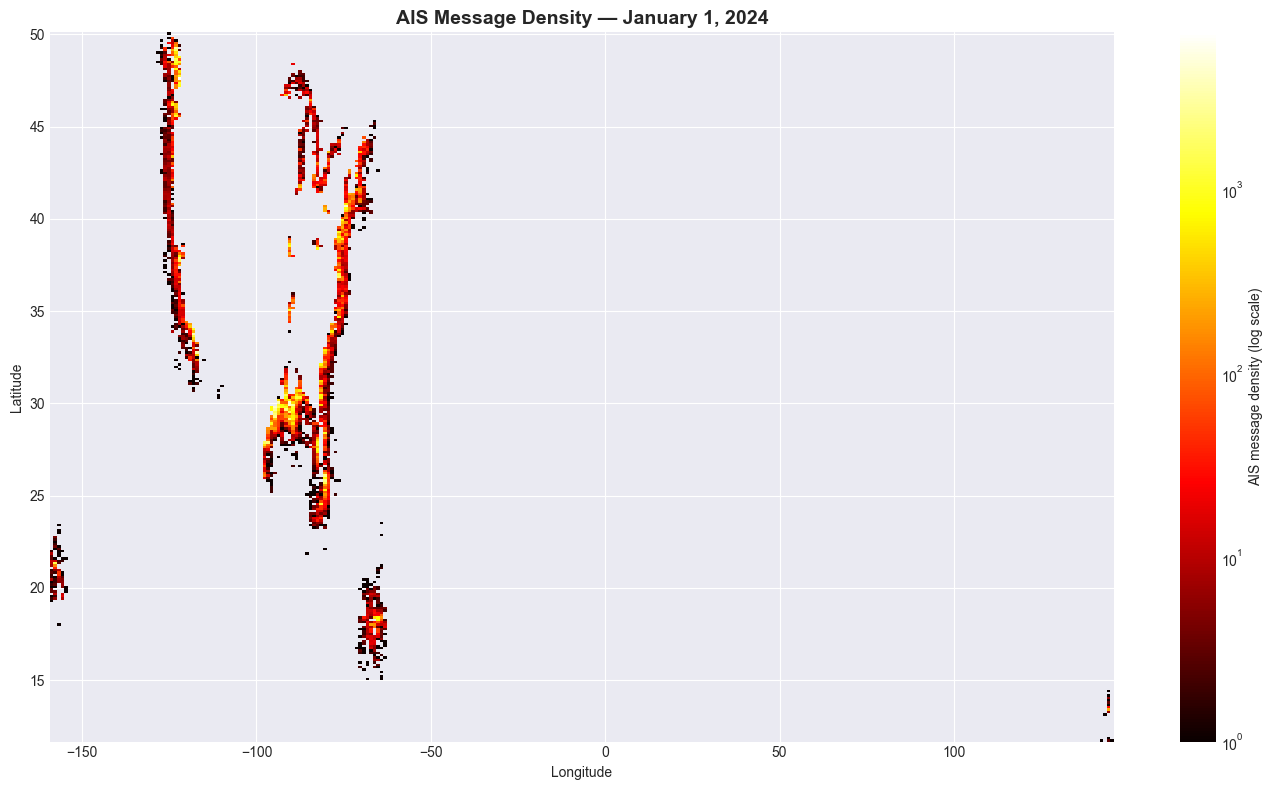

✅ Map saved to data/processed/ais_density_map.png


In [9]:
# Extract lat/lon from geometry
gdf['lon'] = gdf.geometry.x
gdf['lat'] = gdf.geometry.y

print('=== GEOGRAPHIC COVERAGE ===')
print(f'Longitude: {gdf["lon"].min():.2f} → {gdf["lon"].max():.2f}')
print(f'Latitude:  {gdf["lat"].min():.2f} → {gdf["lat"].max():.2f}')

# 2D density heatmap
fig, ax = plt.subplots(figsize=(14, 8))

# Sample for performance
sample = gdf.sample(min(200_000, len(gdf)), random_state=42)

h = ax.hist2d(
    sample['lon'], sample['lat'],
    bins=300,
    cmap='hot',
    norm=mcolors.LogNorm()
)
plt.colorbar(h[3], ax=ax, label='AIS message density (log scale)')
ax.set_title('AIS Message Density — January 1, 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('../data/processed/ais_density_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Map saved to data/processed/ais_density_map.png')

## 6. Navires uniques & trajectoires

🚢 Unique vessels (MMSI): 14,857
📡 Avg messages per vessel: 490.9
📡 Median messages per vessel: 408


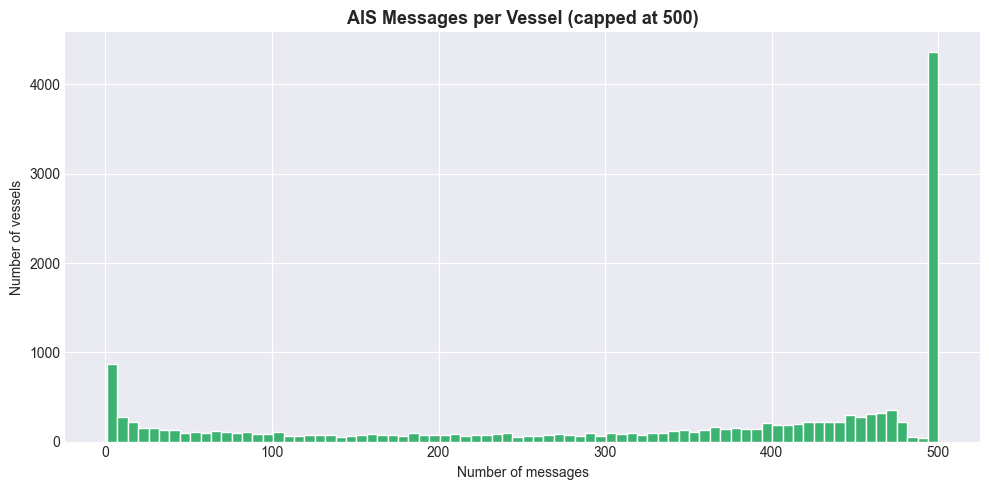


🏆 Top 10 most active vessels:
mmsi
338199855    1411
366921510    1386
368332080    1379
367796610    1379
367669550    1372
368179250    1371
368091590    1370
367458840    1370
367061930    1368
367315830    1367
dtype: int64


In [10]:
# Find MMSI column
mmsi_col = None
for col in ['MMSI', 'mmsi']:
    if col in gdf.columns:
        mmsi_col = col
        break

if mmsi_col:
    n_vessels = gdf[mmsi_col].nunique()
    msgs_per_vessel = gdf.groupby(mmsi_col).size()
    
    print(f'🚢 Unique vessels (MMSI): {n_vessels:,}')
    print(f'📡 Avg messages per vessel: {msgs_per_vessel.mean():.1f}')
    print(f'📡 Median messages per vessel: {msgs_per_vessel.median():.0f}')
    
    fig, ax = plt.subplots(figsize=(10, 5))
    msgs_per_vessel.clip(upper=500).hist(bins=80, ax=ax, color='mediumseagreen', edgecolor='white')
    ax.set_title('AIS Messages per Vessel (capped at 500)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of messages')
    ax.set_ylabel('Number of vessels')
    plt.tight_layout()
    plt.show()
    
    # Top 10 most active vessels
    print('\n🏆 Top 10 most active vessels:')
    print(msgs_per_vessel.sort_values(ascending=False).head(10))
else:
    print('⚠️ MMSI column not found')

## 7. Analyse temporelle

In [11]:
# Find timestamp column
time_col = None
for col in ['BaseDateTime', 'timestamp', 'time', 'DateTime', 'BaseDate']:
    if col in gdf.columns:
        time_col = col
        break

if time_col:
    gdf[time_col] = pd.to_datetime(gdf[time_col])
    gdf['hour'] = gdf[time_col].dt.hour
    
    fig, ax = plt.subplots(figsize=(12, 5))
    gdf['hour'].value_counts().sort_index().plot(kind='bar', ax=ax, color='royalblue')
    ax.set_title('AIS Messages by Hour of Day (UTC)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Hour (UTC)')
    ax.set_ylabel('Number of messages')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Timestamp column not found. Available columns:')
    print(list(gdf.columns))

⚠️ Timestamp column not found. Available columns:
['mmsi', 'base_date_time', 'sog', 'cog', 'heading', 'vessel_name', 'imo', 'call_sign', 'vessel_type', 'status', 'length', 'width', 'draft', 'cargo', 'transceiver', 'geometry', 'vessel_category', 'lon', 'lat']


## 8. Résumé & conclusions pour le pipeline

In [12]:
print('=' * 55)
print('📋 EDA SUMMARY — AIS 2024-01-01')
print('=' * 55)
print(f'  Total rows          : {len(gdf):>12,}')
print(f'  Columns             : {len(gdf.columns):>12}')
if mmsi_col:
    print(f'  Unique vessels      : {gdf[mmsi_col].nunique():>12,}')
if speed_col:
    stopped = (gdf[speed_col] < 0.5).sum()
    outliers = (gdf[speed_col] > 30).sum()
    print(f'  Stopped (SOG<0.5)   : {stopped:>12,}')
    print(f'  Outliers (SOG>30)   : {outliers:>12,}')
print()
print('🔧 PIPELINE DECISIONS:')
print('  → Filter SOG < 0.5 knots (stopped vessels)')
print('  → Filter SOG > 30 knots (outliers)')
print('  → Keep cargo (70x) + tanker (80x) + passenger (60x)')
print('  → Require >= 10 points per trajectory')
print('  → Parse geometry → lat/lon columns')

📋 EDA SUMMARY — AIS 2024-01-01
  Total rows          :    7,293,408
  Columns             :           19
  Unique vessels      :       14,857
  Stopped (SOG<0.5)   :    5,531,374
  Outliers (SOG>30)   :        5,087

🔧 PIPELINE DECISIONS:
  → Filter SOG < 0.5 knots (stopped vessels)
  → Filter SOG > 30 knots (outliers)
  → Keep cargo (70x) + tanker (80x) + passenger (60x)
  → Require >= 10 points per trajectory
  → Parse geometry → lat/lon columns
